# Clasificación CIFAR-10: Regresión Logística Multinomial 

## Objetivo y esquema de trabajo

Este refactor mantiene la lógica del laboratorio original y organiza el flujo en:
1. Carga y preparación de CIFAR-10.
2. Dataset/DataLoader.
3. Definición del modelo multinomial.
4. Entrenamiento por épocas con descenso del gradiente.
5. Validación, test y checkpoints.
6. Predicciones sobre nuevas entradas.


60,000 imágenes RGB de 32×32 píxeles

## Fase 1 Preparacion del sistema

Cargar, procesar y prepararlos datos para el entrenamiento.

### 1.1 Cargar CIFAR-10

CIFAR-10 viene en 6 batches de entrenamiento (50k imagenes) y 1 de test (10k). Cada imagen es de 32x32x3 (RGB) que se aplana a `3072 valores`.

In [78]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pickle
import matplotlib.pyplot as plt


In [79]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

# Cargar nombres de clases
meta = unpickle(ruta_cifar + 'batches.meta')
nombres_clases = [n.decode('utf-8') for n in meta[b'label_names']]
print("Clases:", nombres_clases)

# Cargar datos de entrenamiento (batches 1-5)
X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch = unpickle(f'{ruta_cifar}data_batch_{i}')
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list).astype(np.float32)
y_train = np.array(y_train_list, dtype=np.int64)

# Cargar datos de test
test_batch = unpickle(ruta_cifar + 'test_batch')
X_test = test_batch[b'data'].astype(np.float32)
y_test = np.array(test_batch[b'labels'], dtype=np.int64)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipykernel_9249/3425209956.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fo, encoding='bytes')


Train: (50000, 3072) | Test: (10000, 3072)


In [80]:
import pandas as pd

# Vista tabular opcional de una muestra del dataset
# Se ejecuta solo si X_train e y_train ya existen en memoria.
if 'X_train' in globals() and 'y_train' in globals():
    df_preview = pd.DataFrame(X_train[:6])
    df_preview['label'] = y_train[:6]
    display(df_preview)
else:
    print('Primero ejecutá la celda de carga de CIFAR-10 para definir X_train e y_train.')



,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59.0,43.0,50.0,68.0,98.0,119.0,139.0,145.0,149.0,149.0,...,58.0,65.0,59.0,46.0,57.0,104.0,140.0,84.0,72.0,6
1,154.0,126.0,105.0,102.0,125.0,155.0,172.0,180.0,142.0,111.0,...,42.0,67.0,101.0,122.0,133.0,136.0,139.0,142.0,144.0,9
2,255.0,253.0,253.0,253.0,253.0,253.0,253.0,253.0,253.0,253.0,...,83.0,80.0,69.0,66.0,72.0,79.0,83.0,83.0,84.0,9
3,28.0,37.0,38.0,42.0,44.0,40.0,40.0,24.0,32.0,43.0,...,39.0,59.0,42.0,44.0,48.0,38.0,28.0,37.0,46.0,4
4,170.0,168.0,177.0,183.0,181.0,177.0,181.0,184.0,189.0,189.0,...,88.0,85.0,82.0,83.0,79.0,78.0,82.0,78.0,80.0,1
5,159.0,150.0,153.0,154.0,138.0,184.0,154.0,77.0,61.0,64.0,...,18.0,16.0,12.0,13.0,16.0,14.0,14.0,17.0,19.0,1


### 1.1.1 Qué significan los números del dataset

En CIFAR-10 cada imagen está guardada como un vector de **3072 números**.

- Los primeros 1024 números son el canal **R** (rojo)
- Los siguientes 1024 son **G** (verde)
- Los últimos 1024 son **B** (azul)

Cada número representa intensidad de color entre **0 y 255**:
- 0 = sin intensidad
- 255 = intensidad máxima

Por eso vemos arreglos numéricos: son los pixeles de la imagen en formato plano.
Luego los reordenamos a forma `(3, 32, 32)` para visualizar correctamente.



Etiqueta numérica: 6 | Clase: frog
Primeros 20 valores del vector plano:
[ 59  43  50  68  98 119 139 145 149 149 131 125 142 144 137 129 137 134
 124 139]


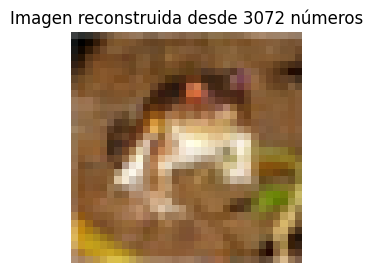

In [81]:
# Visualizar números crudos + imagen reconstruida
idx = 0
print('Etiqueta numérica:', y_train[idx], '| Clase:', nombres_clases[y_train[idx]])
print('Primeros 20 valores del vector plano:')
print(X_train[idx][:20].astype(int))

img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
plt.figure(figsize=(3,3))
plt.imshow(img)
plt.title('Imagen reconstruida desde 3072 números')
plt.axis('off')
plt.show()



In [82]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict


### 1.2 Visualizacion de muestras

Esto confirma que los datos se cargaron bien y muestran las 10 clases

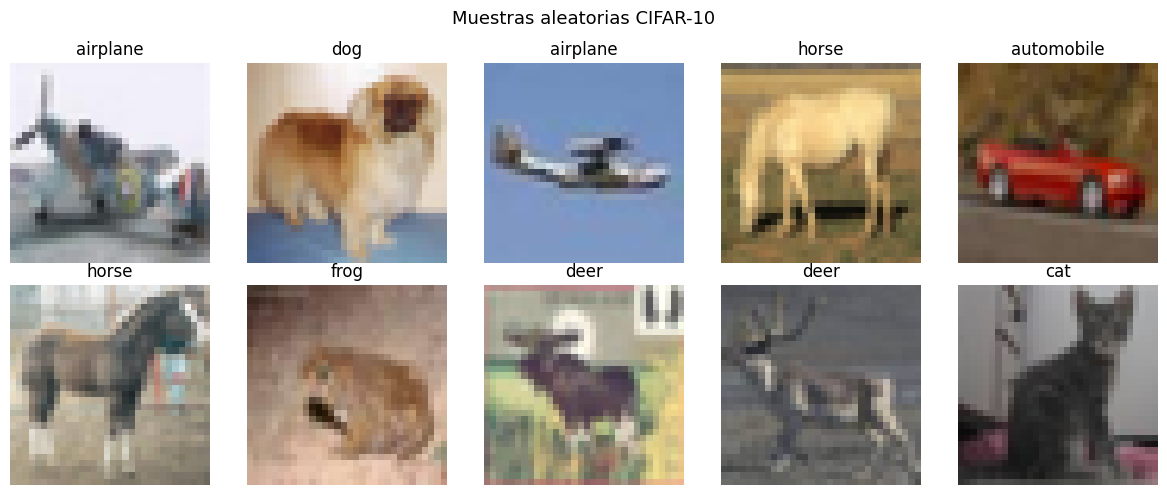

In [83]:
# Visualizar 10 muestras aleatorias
rng = np.random.default_rng(42)
indices = rng.choice(len(X_train), 30, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), indices):
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(nombres_clases[y_train[idx]])
    ax.axis('off')
plt.suptitle("Muestras aleatorias CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()


### 1.3 Split estratificado Train/Validacion

Split 40k train / 10k val / 10k test.

Estratificado para mantener procion de clases

In [84]:
# Split 80/20 estratificado por clase

rng2 = np.random.default_rng(42)
idx_tr, idx_val = [], []
for c in range(10):
    idx_c = rng2.permutation(np.where(y_train == c)[0])
    n_val = int(len(idx_c) * 0.2)
    idx_val.append(idx_c[:n_val])
    idx_tr.append(idx_c[n_val:])

idx_tr = np.concatenate(idx_tr); rng2.shuffle(idx_tr)
idx_val = np.concatenate(idx_val); rng2.shuffle(idx_val)

X_tr, y_tr = X_train[idx_tr] / 255.0, y_train[idx_tr]
X_val, y_val = X_train[idx_val] / 255.0, y_train[idx_val]
X_te = X_test / 255.0

# Normalización con media/std del train
mean_tr = X_tr.mean(axis=0)
std_tr = X_tr.std(axis=0) + 1e-8
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}")


Train: (40000, 3072) | Val: (10000, 3072) | Test: (10000, 3072)


### 1.4 Dataset y DataLoader

CIFAR10Dataset hereda torch.utils.data.Dataset, normaliza en __init__ DataLoader maneja batches y shuffle

In [85]:
from torch.utils.data import Dataset, DataLoader

class CIFAR10Dataset(Dataset):
    """Dataset personalizado para CIFAR-10 con normalización media/std."""
    def __init__(self, X, y, mean=None, std=None):
        if mean is None: mean = X.mean(axis=0)
        if std is None: std = X.std(axis=0) + 1e-8
        X_norm = (X - mean) / std
        self.X = torch.tensor(X_norm, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_ds = CIFAR10Dataset(X_tr, y_tr, mean=mean_tr, std=std_tr)
val_ds   = CIFAR10Dataset(X_val, y_val, mean=mean_tr, std=std_tr)
test_ds  = CIFAR10Dataset(X_te, y_test, mean=mean_tr, std=std_tr)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches/epoch → train: {len(train_loader)} | val: {len(val_loader)}")


Batches/epoch → train: 157 | val: 40


### 1.5 Verificacion de DataLoader

In [86]:
# Prbar un batch 
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape} | Batch y: {yb.shape}")
print(f"Valores X: min={xb.min():.3f}, max={xb.max():.3f}, mean={xb.mean():.3f}")
print(f"Clases en batch: {torch.unique(yb)}")


Batch X: torch.Size([256, 3072]) | Batch y: torch.Size([256])
Valores X: min=-2.202, max=2.627, mean=0.047
Clases en batch: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


## Fase 2 Arquitectua del modelo con `Sequential`

### 2.1 Componentes del modelo

`nn.Linear` -- La capa densa
Es la capa principal de un MLP. Hace una transformacion matematica:

$y=xW^T+b$

Donde `x` es la entrada, `W` son los pesos (lo que aprende) y `b` es el bias

In [87]:
nn.Linear(3072, 1024)


Linear(in_features=3072, out_features=1024, bias=True)

### 2.2 Modelo Completo

In [88]:
import torch
from torch import nn

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando: {DEVICE}")

modelo = nn.Sequential(
    # Bloque 1: 3072 -> 512
    nn.Linear(3072, 512),
    nn.ReLU(),
    nn.Dropout(0.3),

    # Bloque 2: 512 -> 256
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),

    # Bloque 3: 256 -> 128
    nn.Linear(256, 128),
    nn.ReLU(),

    # Salida: 128 -> 10 clases
    nn.Linear(128, 10)
)

print(modelo)



Usando: cuda
Sequential(
  (0): Linear(in_features=3072, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Linear(in_features=128, out_features=10, bias=True)
)


### 2.3 Contar parametros Entrenables

Resultado esperado alrededor de 3.9millones de parametros. Cada uno de esos es un numero que el modelo ajusta durante el entrenamiento para aprender a clasificar

In [89]:
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")


Parámetros entrenables: 1,738,890


### 2.4 Verificar que el modelo funciona

In [90]:
# Probar con un batch falso antes de entrenar con datos reales
x_prueba = torch.randn(8, 3072)  # 8 imágenes falsas
out = modelo(x_prueba)
print(f"Input:  {x_prueba.shape}")   # → torch.Size([8, 3072])
print(f"Output: {out.shape}")        # → torch.Size([8, 10])


Input:  torch.Size([8, 3072])
Output: torch.Size([8, 10])


## Fase 3 Entrenamiento

### 3.1 Función de pérdida y optimizador

`SGD` es el optimizador mas basico que existe: mueve los pesos en la direccion que reduce el error:

$w=w−lr×gradiente$

Nada mas. `lr=0.01` es el tamano del paso de correcion en cada batch

In [91]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=0.001)


### 3.2 El loop de entrenamiento

In [92]:
import os
import numpy as np
os.makedirs('./checkpoints', exist_ok=True)

EPOCHS    = 10
BEST_PATH = './checkpoints/mejor_modelo.pth'
best_val_acc = 0.0

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

modelo = modelo.to(DEVICE)

print(f'Inicio entrenamiento: {EPOCHS} epocas')
for epoch in range(1, EPOCHS + 1):

    # ── ENTRENAMIENTO ──────────────────────────────────────
    modelo.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        y_hat = modelo(xb)                              # forward
        loss  = criterion(y_hat, yb)                   # pérdida

        optimizer.zero_grad()                          # limpiar gradientes
        loss.backward()                                # calcular gradientes
        optimizer.step()                               # actualizar pesos

        train_loss    += loss.item() * xb.size(0)
        train_correct += (torch.argmax(y_hat, axis=1) == yb).sum().item()
        train_total   += yb.size(0)

    # ── VALIDACIÓN ─────────────────────────────────────────
    modelo.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            y_hat  = modelo(xb)
            loss   = criterion(y_hat, yb)
            val_loss    += loss.item() * xb.size(0)
            val_correct += (torch.argmax(y_hat, axis=1) == yb).sum().item()
            val_total   += yb.size(0)

    # ── MÉTRICAS ───────────────────────────────────────────
    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total * 100
    v_loss = val_loss  / val_total
    v_acc  = val_correct  / val_total  * 100

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    # ── BEST MODEL CHECKPOINT ──────────────────────────────
    # (04-pytorch_save.ipynb — "guardar modelo si es el mejor")
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(modelo.state_dict(), BEST_PATH)
        print(f"  ✓ Mejor modelo guardado (val_acc={v_acc:.2f}%)")

    print(f"Época {epoch:2d}/{EPOCHS} | "
          f"loss={t_loss:.4f}  acc={t_acc:.2f}% | "
          f"val_loss={v_loss:.4f}  val_acc={v_acc:.2f}%")

# ── CARGAR EL MEJOR MODELO AL FINAL ────────────────────────
# (04-pytorch_save.ipynb — "cargar el mejor modelo al final del entrenamiento")
modelo.load_state_dict(torch.load(BEST_PATH, weights_only=True))
print(f"\n✅ Listo. Mejor val_acc: {best_val_acc:.2f}%")


Inicio entrenamiento: 10 epocas
  ✓ Mejor modelo guardado (val_acc=9.11%)
Época  1/10 | loss=2.3053  acc=9.05% | val_loss=2.3024  val_acc=9.11%
  ✓ Mejor modelo guardado (val_acc=10.51%)
Época  2/10 | loss=2.3015  acc=9.90% | val_loss=2.2984  val_acc=10.51%
  ✓ Mejor modelo guardado (val_acc=12.71%)
Época  3/10 | loss=2.2980  acc=10.76% | val_loss=2.2944  val_acc=12.71%
  ✓ Mejor modelo guardado (val_acc=14.63%)
Época  4/10 | loss=2.2941  acc=12.20% | val_loss=2.2904  val_acc=14.63%
  ✓ Mejor modelo guardado (val_acc=15.95%)
Época  5/10 | loss=2.2902  acc=13.51% | val_loss=2.2862  val_acc=15.95%
  ✓ Mejor modelo guardado (val_acc=16.83%)
Época  6/10 | loss=2.2861  acc=14.79% | val_loss=2.2818  val_acc=16.83%
  ✓ Mejor modelo guardado (val_acc=17.52%)
Época  7/10 | loss=2.2818  acc=15.83% | val_loss=2.2772  val_acc=17.52%
  ✓ Mejor modelo guardado (val_acc=18.09%)
Época  8/10 | loss=2.2774  acc=16.86% | val_loss=2.2721  val_acc=18.09%
  ✓ Mejor modelo guardado (val_acc=18.77%)
Época  9/

## Fase 4 Validacion y ajuste

### 4.1 Curvas de Entrenamiento

| Lo que ves               | Qué significa                      |
| ------------------------ | ---------------------------------- |
| Train ↓ y Val ↓ juntas   | ✅ Modelo aprendiendo bien          |
| Train ↓ y Val se estanca | ⚠️ Sobreajuste comenzando          |
| Train ↓↓ y Val ↑         | ❌ Sobreajuste severo (overfitting) |
| Ambas altas y estancadas | ❌ Subajuste (underfitting)         |

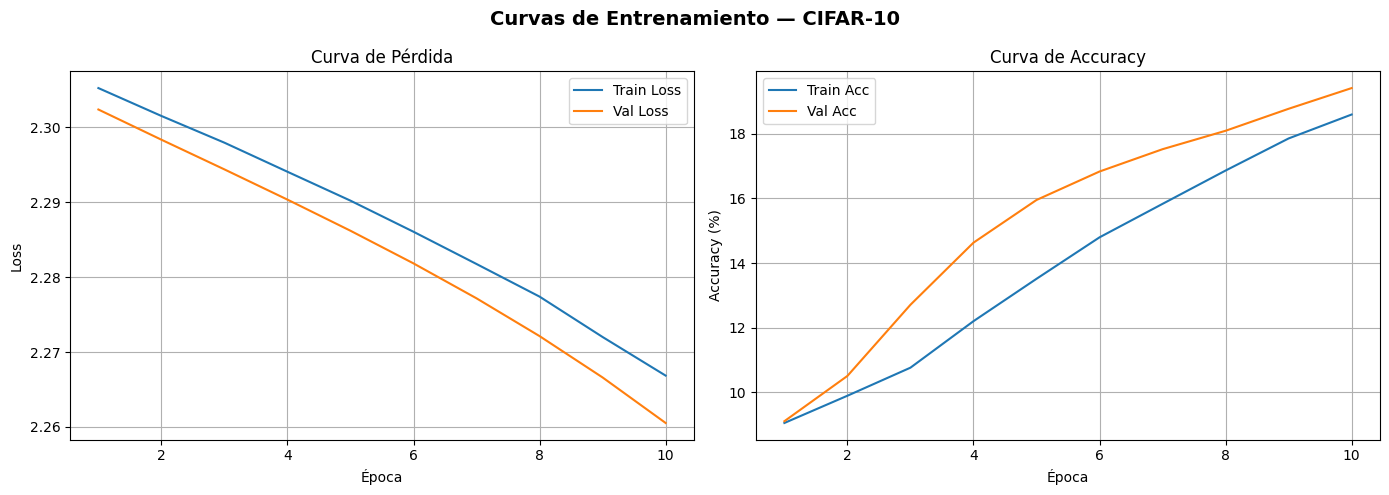

In [93]:
import matplotlib.pyplot as plt

epocas = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica de Loss ──────────────────────────────────────
ax1.plot(epocas, history['train_loss'], label='Train Loss')
ax1.plot(epocas, history['val_loss'],   label='Val Loss')
ax1.set_title('Curva de Pérdida')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# ── Gráfica de Accuracy ──────────────────────────────────
ax2.plot(epocas, history['train_acc'], label='Train Acc')
ax2.plot(epocas, history['val_acc'],   label='Val Acc')
ax2.set_title('Curva de Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Curvas de Entrenamiento — CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.2 Evaluacion final en test

Cargamos el mejor modelo con load_state_disct, no el ultimo. Le ultimo puede estar sobreajustado, el mejor es el que tuvo mayor val_acc durante todo el entrenamiento

In [94]:
# Cargar el MEJOR modelo (no el último)
best_model = nn.Sequential(
    nn.Linear(3072, 512), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(512, 256),  nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 128),  nn.ReLU(),
    nn.Linear(128, 10)
)
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.eval()
best_model = best_model.to(DEVICE)

# Evaluar en test
test_correct, test_total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = best_model(xb)
        test_correct += (torch.argmax(logits, axis=1) == yb).sum().item()
        test_total   += yb.size(0)

test_acc = test_correct / test_total * 100
print(f"Accuracy en Test: {test_acc:.2f}%")



Accuracy en Test: 20.48%


### 4.3 Visualizar predicciones reales

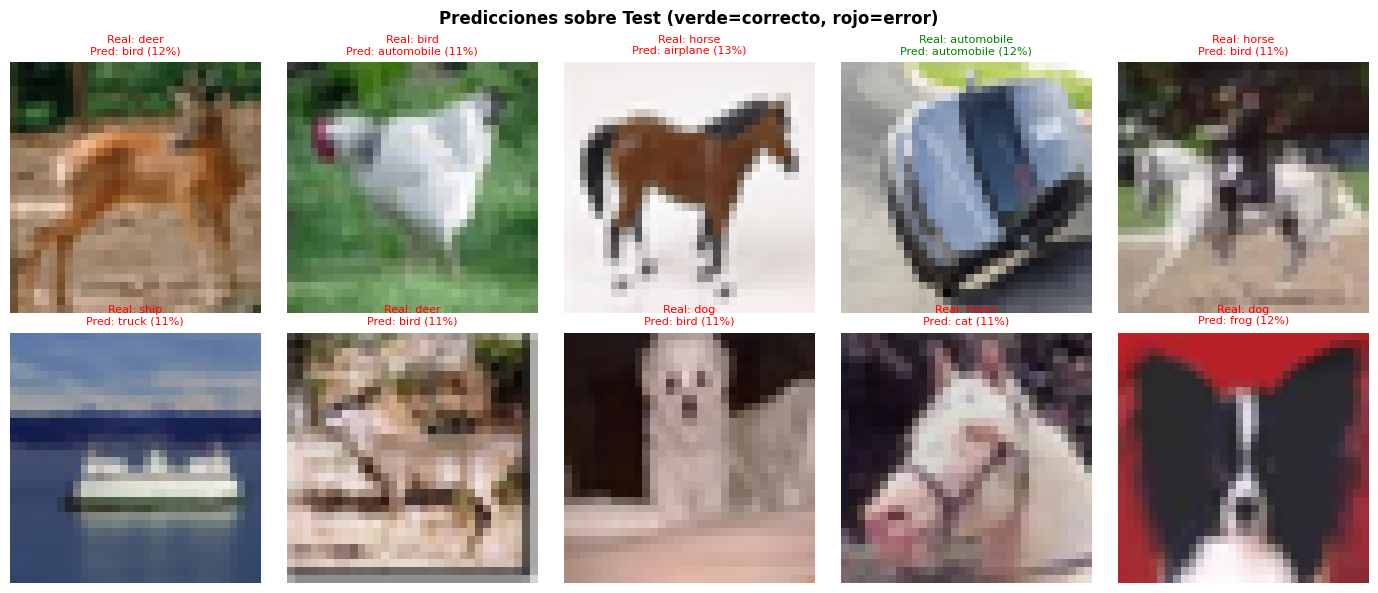

In [ ]:
rng_prueba = np.random.default_rng(99)
idx_prueba = rng_prueba.choice(len(X_te), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, idx in zip(axes.flatten(), idx_prueba):
    # Imagen original (solo /255, sin normalización para visualizar)
    img = X_te[idx].reshape(3, 32, 32).transpose(1, 2, 0)

    # Preprocesar con la normalización del entrenamiento
    x_norm  = (X_te[idx] - mean_tr) / std_tr
    x_input = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # Predicción
    with torch.no_grad():
        probs      = torch.softmax(best_model(x_input), dim=1)[0]
        pred_idx   = probs.argmax().item()
        pred_nombre = nombres_clases[pred_idx]
        confianza  = probs[pred_idx].item() * 100

    real_nombre  = nombres_clases[y_test[idx]]
    color_titulo = 'green' i"Actúa como un experto en Python, análisis de datos y simulación de sistemas. Escribe un script en Python que simule un problema económico: la distribución de ingresos de una población elegida al azar (medida en miles de unidades monetarias).
Para esto, debes simular una distribución lognormal utilizando su relación matemática con la distribución normal estándar, sin usar funciones directas que generen la lognormal automáticamente (como numpy.random.lognormal), sino programando el algoritmo subyacente paso a paso.
Parámetros del modelo:

    Parámetro de ubicación (media del logaritmo natural): μ=2
    Parámetro de escala (desviación estándar del logaritmo natural): σ=1
    Número de iteraciones (Simulación de Montecarlo): 10,000

Instrucciones lógicas para el algoritmo:

    Crea un bucle que se repita 10,000 veces.
    En cada iteración, genera un número pseudoaleatorio Z que siga una distribución normal estándar (media 0 y varianza 1). Puedes usar numpy.random.standard_normal para este paso específico.
    Transforma este valor normal estándar en un valor aleatorio lognormal X aplicando la fórmula de transformación exponencial: X=exp(μ+σ∗Z).
    Almacena cada ingreso X generado en una lista o arreglo.

Resultados esperados del código: Al finalizar el bucle de simulación, el script debe calcular e imprimir en consola lo siguiente:

    El promedio empírico (la media) de los 10,000 ingresos simulados.
    El valor esperado teórico del ingreso calculado con la fórmula matemática exacta: E(X)=exp(μ+0.5∗σ2).
    Una comparación sencilla que muestre qué tan cerca estuvo la simulación del valor teórico esperado.
    (Opcional pero recomendado) Generar un histograma utilizando matplotlib o seaborn para visualizar el sesgo a la derecha característico de esta distribución en los ingresos.

Por favor, incluye comentarios en el código que expliquen la fórmula exponencial utilizada."

--------------------------------------------------------------------------------
¿Por qué este prompt es efectivo?

    Aplica la teoría de tus fuentes: Obliga al generador de código a utilizar la fórmula X=eμ+σZ en lugar de atajos de las librerías, garantizando que el modelo matemático se simule correctamente desde sus bases.
    Verificación estadística: Al pedir que compare el promedio simulado con la esperanza matemática teórica E(X)=exp(μ+21​σ2), tendrás una prueba inmediata de que tu simulación funciona correctamente (ambos valores deberían rondar los 12.18 miles de unidades monetarias)f pred_idx == y_test[idx] else 'red'

    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(
        f"Real: {real_nombre}\nPred: {pred_nombre} ({confianza:.0f}%)",
        fontsize=8, color=color_titulo
    )
    ax.axis('off')

plt.suptitle("Predicciones sobre Test (verde=correcto, rojo=error)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Fase 5 Pruebafinal y exportacion

---
## Definiciones Auxiliares

Las siguientes clases y funciones son necesarias para las secciones 5 y 6.

In [96]:
from torch import nn

class MLP_CIFAR10(nn.Module):
    """MLP con BatchNorm y Dropout para CIFAR-10."""
    def __init__(self, in_features=3072, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(in_features, 512)
        self.bn1   = nn.BatchNorm1d(512)
        self.act1  = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.fc2   = nn.Linear(512, 256)
        self.bn2   = nn.BatchNorm1d(256)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.fc3  = nn.Linear(256, 128)
        self.act3 = nn.ReLU()
        self.out  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.drop1(self.act1(self.bn1(self.fc1(x))))
        x = self.drop2(self.act2(self.bn2(self.fc2(x))))
        x = self.act3(self.fc3(x))
        return self.out(x)

model_demo = MLP_CIFAR10()
total_params = sum(p.numel() for p in model_demo.parameters() if p.requires_grad)
print(f"MLP_CIFAR10 definida ✓  |  Parámetros entrenables: {total_params:,}")



MLP_CIFAR10 definida ✓  |  Parámetros entrenables: 1,740,426


In [97]:
import os
import torch
from torch import nn

def fit(model, train_loader, val_loader,
        epochs=5, lr=1e-3,
        best_path='./checkpoints/best_model.pth',
        resume_path='./checkpoints/resume_checkpoint.pth',
        backup_every=5,
        device='cpu'):
    """Loop de entrenamiento con best-model + resume-from-checkpoint."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    start_epoch = 1
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    if resume_path and os.path.exists(resume_path):
        print(f"▶ Reanudando entrenamiento desde: {resume_path}")
        ckpt = torch.load(resume_path, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        history      = ckpt['history']
        print(f"   → Continuando desde época {start_epoch} | mejor val_acc: {best_val_acc:.2f}%")
    else:
        print("▶ Entrenamiento desde cero.")

    print(f'Inicio entrenamiento: {epochs} epocas')
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * xb.size(0)
            t_correct += (logits.argmax(1) == yb).sum().item()
            t_total   += yb.size(0)
        scheduler.step()

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss   = criterion(logits, yb)
                v_loss    += loss.item() * xb.size(0)
                v_correct += (logits.argmax(1) == yb).sum().item()
                v_total   += yb.size(0)

        tl = t_loss / t_total;  ta = t_correct / t_total * 100
        vl = v_loss / v_total;  va = v_correct / v_total * 100
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), best_path)
            print(f"   ✓ Mejor modelo guardado (val_acc={va:.2f}%)")

        if epoch % backup_every == 0:
            ckpt = {
                'epoch': epoch, 'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'history': history, 'best_val_acc': best_val_acc,
            }
            torch.save(ckpt, resume_path)
            print(f"   💾 Backup guardado (época {epoch}/{epochs})")

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"loss={tl:.4f} acc={ta:.2f}% | "
              f"val_loss={vl:.4f} val_acc={va:.2f}%")

    model.load_state_dict(torch.load(best_path, weights_only=True))
    print(f"\n✅ Entrenamiento finalizado. Mejor val_acc: {best_val_acc:.2f}%")
    return history

print("Función fit() definida ✓")




Función fit() definida ✓


### 5.1 Guardar el modelo completo

Guarda arquitectura + pesos en un solo archivo con torch.save(model, path)

In [98]:
# Guardar
torch.save(modelo, './checkpoints/mlp_completo.pt')

# Cargar — NO necesitas la arquitectura explícita, pero sí la clase definida
model_full = torch.load('./checkpoints/mlp_completo.pt', weights_only=False)
model_full.eval()
print('Modelo completo cargado ✓')


Modelo completo cargado ✓


## Fase 6 Trabajo real

### CIFAR-10 viene en 5 archivos binarios de entrenamiento + 1 de test:

In [99]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

meta = unpickle(ruta_cifar + 'batches.meta')
nombres_clases = [n.decode('utf-8') for n in meta[b'label_names']]
# → ['airplane', 'automobile', 'bird', 'cat', 'deer',
#    'dog', 'frog', 'horse', 'ship', 'truck']

X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch = unpickle(f'{ruta_cifar}data_batch_{i}')
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list).astype(np.float32)  # (50000, 3072)
y_train = np.array(y_train_list, dtype=np.int64)

test_batch = unpickle(ruta_cifar + 'test_batch')
X_test = test_batch[b'data'].astype(np.float32)        # (10000, 3072)
y_test = np.array(test_batch[b'labels'], dtype=np.int64)


/tmp/ipykernel_9249/340492588.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fo, encoding='bytes')


## Split Estratificado Train / Val

In [100]:
rng2 = np.random.default_rng(42)
idx_tr, idx_val = [], []

for c in range(10):               # por cada una de las 10 clases
    idx_c = rng2.permutation(np.where(y_train == c)[0])
    n_val = int(len(idx_c) * 0.2) # 20% para validación
    idx_val.append(idx_c[:n_val])
    idx_tr.append(idx_c[n_val:])

idx_tr  = np.concatenate(idx_tr);  rng2.shuffle(idx_tr)
idx_val = np.concatenate(idx_val); rng2.shuffle(idx_val)

# Normalizar a [0, 1] dividiendo por 255
X_tr,  y_tr  = X_train[idx_tr]  / 255.0, y_train[idx_tr]
X_val, y_val = X_train[idx_val] / 255.0, y_train[idx_val]
X_te         = X_test            / 255.0

# Media y std solo del train (no contaminar val/test)
mean_tr = X_tr.mean(axis=0)
std_tr  = X_tr.std(axis=0) + 1e-8
# → Train: (40000, 3072) | Val: (10000, 3072) | Test: (10000, 3072)


### Datasets y DataLoaders

In [101]:
BATCH_SIZE = 256

train_ds = CIFAR10Dataset(X_tr,  y_tr,  mean=mean_tr, std=std_tr)
val_ds   = CIFAR10Dataset(X_val, y_val, mean=mean_tr, std=std_tr)
test_ds  = CIFAR10Dataset(X_te,  y_test, mean=mean_tr, std=std_tr)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
# → Batches/epoch → train: 157 | val: 40


### Modelo y Dispositivo

In [102]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")  # → cuda (en el lab)

model = MLP_CIFAR10(in_features=3072, num_classes=10)
# → Parámetros: 3,808,522


Dispositivo: cuda


### Tu propia imagen

In [103]:
from PIL import Image
import tkinter as tk
from tkinter import filedialog

root = tk.Tk(); root.withdraw()
ruta = filedialog.askopenfilename(
    title="Selecciona una imagen",
    filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp *.webp")]
)
root.destroy()

# Asegurar mismo device para modelo e input
best_model = best_model.to(DEVICE)
best_model.eval()

# Preprocesar: resize a 32x32, flatten, normalizar
img_pil   = Image.open(ruta).convert('RGB').resize((32, 32))
img_flat  = np.array(img_pil, dtype=np.float32) / 255.0
img_flat  = img_flat.transpose(2, 0, 1).flatten()    # (3072,)
img_norm  = (img_flat - mean_tr) / std_tr
x_in      = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits     = best_model(x_in)
    probs      = torch.softmax(logits, dim=1)[0]
    clase_idx  = probs.argmax().item()
    confianza  = probs[clase_idx].item() * 100

print(f"Predicción: {nombres_clases[clase_idx].upper()} ({confianza:.1f}%)")



Predicción: AUTOMOBILE (11.2%)


### Mejor exactitud por checkpoint

Esta gráfica muestra la mayor exactitud de validación guardada en el checkpoint de reanudación.


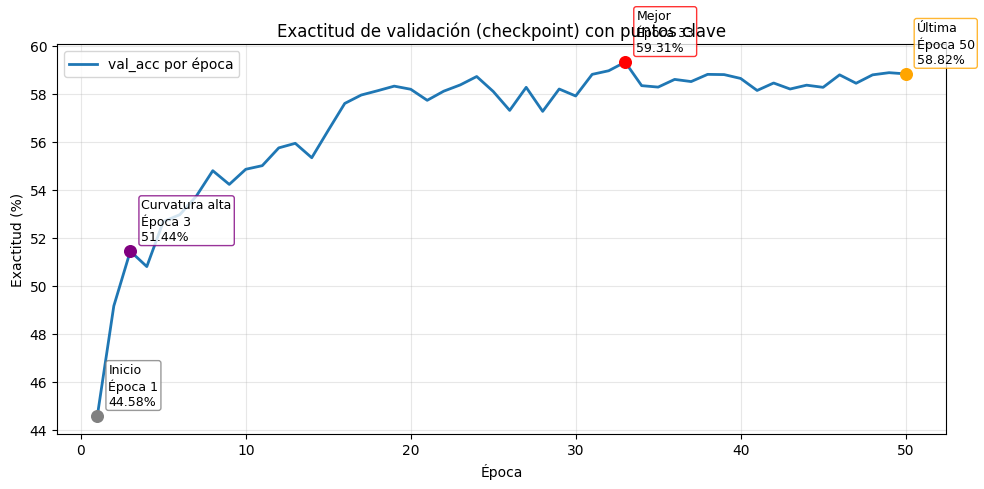

Checkpoint usado: ./checkpoints/resume_checkpoint.pth
Mejor exactitud: 59.31% en época 33
Última época: 50 con exactitud 58.82%
Punto de mayor curvatura: época 3 con exactitud 51.44%


In [104]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

candidates = [
    './checkpoints/resume_checkpoint_small.pth',
    './checkpoints/resume_checkpoint.pth'
]

found = None
for ck in candidates:
    if os.path.exists(ck):
        found = ck
        break

if found is None:
    print('No se encontró checkpoint de resume para graficar exactitud.')
else:
    ckpt = torch.load(found, map_location='cpu', weights_only=False)
    hist = ckpt.get('history', {})
    val_acc_hist = hist.get('val_acc', [])

    if len(val_acc_hist) == 0:
        print(f'Checkpoint encontrado: {found}, pero no contiene history["val_acc"].')
    else:
        val_acc_hist = np.array(val_acc_hist, dtype=float)
        epochs = np.arange(1, len(val_acc_hist) + 1)

        # Puntos clave
        best_idx = int(np.argmax(val_acc_hist))
        best_epoch = int(epochs[best_idx])
        best_acc = float(val_acc_hist[best_idx])

        last_idx = len(val_acc_hist) - 1
        last_epoch = int(epochs[last_idx])
        last_acc = float(val_acc_hist[last_idx])

        first_idx = 0
        first_epoch = int(epochs[first_idx])
        first_acc = float(val_acc_hist[first_idx])

        # Curvatura aproximada (segunda diferencia)
        if len(val_acc_hist) >= 3:
            second_diff = np.abs(np.diff(val_acc_hist, n=2))
            curv_idx = int(np.argmax(second_diff)) + 1
        else:
            curv_idx = best_idx
        curv_epoch = int(epochs[curv_idx])
        curv_acc = float(val_acc_hist[curv_idx])

        plt.figure(figsize=(10, 5))
        plt.plot(epochs, val_acc_hist, label='val_acc por época', linewidth=2)

        key_points = [
            ('Inicio', first_epoch, first_acc, 'gray'),
            ('Mejor', best_epoch, best_acc, 'red'),
            ('Última', last_epoch, last_acc, 'orange'),
            ('Curvatura alta', curv_epoch, curv_acc, 'purple')
        ]

        for name, ep, acc, color in key_points:
            plt.scatter([ep], [acc], color=color, s=70, zorder=4)
            label = f"{name}\nÉpoca {ep}\n{acc:.2f}%"
            plt.annotate(
                label,
                (ep, acc),
                textcoords='offset points',
                xytext=(8, 8),
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8)
            )

        plt.title('Exactitud de validación (checkpoint) con puntos clave')
        plt.xlabel('Época')
        plt.ylabel('Exactitud (%)')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f'Checkpoint usado: {found}')
        print(f'Mejor exactitud: {best_acc:.2f}% en época {best_epoch}')
        print(f'Última época: {last_epoch} con exactitud {last_acc:.2f}%')
        print(f'Punto de mayor curvatura: época {curv_epoch} con exactitud {curv_acc:.2f}%')

